**Question 4, part d**

In [3]:
import numpy as np
import matplotlib.pyplot as plt

vt = 2
w = 5.0 mV
mean = 10.21089040968564 mV
variance = 25.248189175848733 mV^2
skewness = 0.6842999191102352



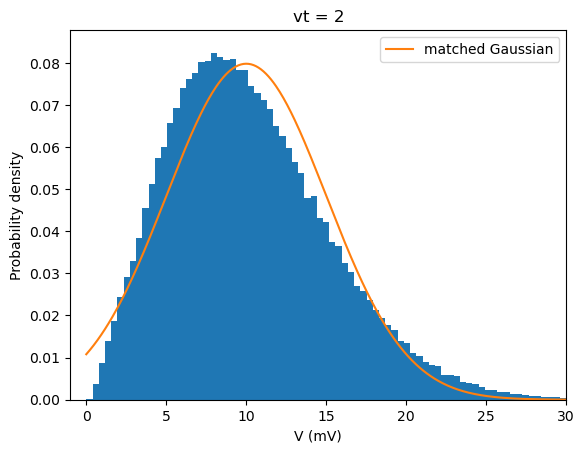

vt = 20
w = 1.5811388300841898 mV
mean = 9.969648946000273 mV
variance = 25.070537956868563 mV^2
skewness = 0.09214101748312181



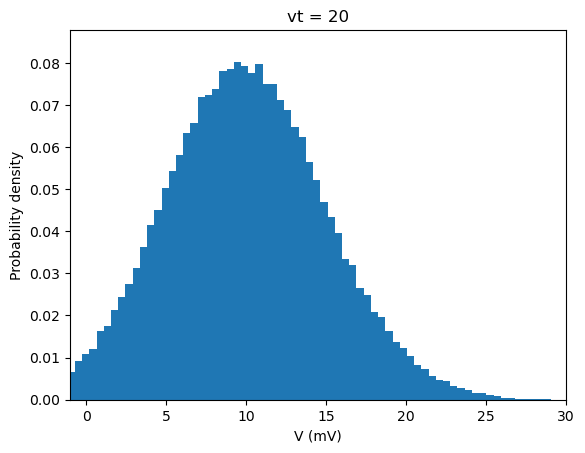

vt = 200
w = 0.5 mV
mean = 9.902444201541705 mV
variance = 24.872656399233186 mV^2
skewness = -0.0219404496610738



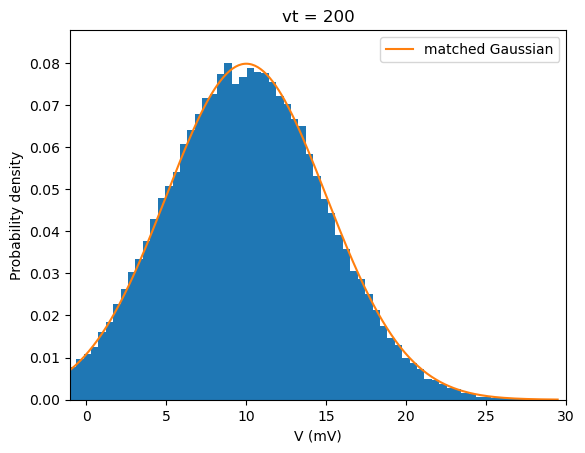

In [21]:
vt_vals = [2,20,200]

for i in vt_vals:
    w = np.sqrt(50/i)
    diff = 10/w
    
    ve = (diff+i)/2 /0.020
    vi = (i-diff)/2 /0.020
    #used mean to determine how much excitation and inhibition needed for mean and variance to be fixed

    excita_times = []
    t = 0

    while t < 100:
        #max simulation run time is 100 
        t += np.random.exponential(1 / ve)
        #this is because a Poisson with rate v has exponentially distributed event times

        if t < 100:
            excita_times.append(t)

    inhib_times = []
    t = 0

    if vi > 0:

        while t < 100:
            t += np.random.exponential(1 / vi)

            if t < 100:
                inhib_times.append(t)

    events_e = [(t,w) for t in excita_times]
    events_i = [(j,-w) for j in inhib_times]

    events = events_e + events_i
    events.sort()

    
    tk_list = np.arange(0, 100, 0.001) #want to sample every 0.001 seconds
    V = np.zeros(len(tk_list))

    V_curr = 0
    last_event = 0
    event_idx = 0

    for n, tk in enumerate(tk_list):
        while (event_idx < len(events) and events[event_idx][0] <= tk):
            #need to go through all the events that occured by the sample time tk
            event_time, jump = events[event_idx]

            # Decay from last event
            V_curr *= np.exp(-(event_time - last_event) / 0.020)

            #Jump from the current event 
            V_curr += jump

            last_event = event_time
            event_idx += 1
            #looping through event list and keeping track of last event

        #save what the voltage is up to the sample time tk
        V_sample = V_curr * np.exp(-(tk - last_event) / 0.020)
        V[n] = V_sample

    
    mean_V = np.mean(V)
    var_V = np.var(V)
    skew = np.mean((V - mean_V)**3) / np.std(V)**3

    print(f"vt = {i}")
    print(f"w = {w} mV")
    print(f"mean = {mean_V} mV")
    print(f"variance = {var_V} mV^2")
    print(f"skewness = {skew}")
    print()

    plt.figure()
    plt.hist(V, bins=100, density=True)
    plt.xlabel("V (mV)")
    plt.ylabel("Probability density")
    plt.title(f"vt = {i}")

    if (i==2) or (i==200):
        mu = 10   
        sigma = 5
        #use theoretical values to showcase if simulation matches with Gaussian

        x = np.linspace(min(V), max(V), 500)
        gaussian = np.exp(-(x -10)**2 / (2*5**2)) / (5 * np.sqrt(2*np.pi))       

        plt.plot(x, gaussian,label = 'matched Gaussian')
        plt.legend()
        
    plt.xlim(-1, 30)
    plt.ylim(0, max(gaussian) * 1.1)
    plt.show()